In [ ]:
# TODO: fix log wis scale in table colours

# TODO: selection figure
# TODO: make sure ranks based on all models

## Google Internal Hub — Component Model Analysis

This notebook evaluates the performance of Google's internal component models submitted to the
[google-research/google-research](https://github.com/google-research/google-research/tree/master/epi_forecasts)
hub for three disease targets: COVID-19, Influenza, and RSV weekly incident hospitalizations.

Models are named `Google_SAI-{Type}_{N}` where Type ∈ {Adapted, Hybrid, Novel}.

Analyses:
1. **Model inventory** — submission coverage by disease and model type
2. **Coverage heatmaps** — which models submitted for which dates/locations
3. **Within-Google performance** — season-average WIS/log-WIS by model type
4. **Performance by horizon** — how forecast quality varies with lead time
5. **Performance over time** — weekly WIS trends across the season
6. **Cross-hub comparison** — Google internal models vs top CDC hub performers

### imports & setup

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import re as _re
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

from hub_config import GOOGLE_COVID_HUB, GOOGLE_FLU_HUB, GOOGLE_RSV_HUB
from hub_config import COVID_HUB, FLU_HUB, RSV_HUB
from src.scoring import pairwise_relative_wis
import src.plotting as P
import src.colouring as C

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 12,          # base size
    "axes.titlesize": 16,     # subplot title
    "axes.labelsize": 15,     # x/y axis labels
    "xtick.labelsize": 12,    # x tick labels
    "ytick.labelsize": 12,    # y tick labels
    "legend.fontsize": 12,    # legend text
    "legend.title_fontsize": 12,
    "figure.titlesize": 18,   # suptitle
})

In [4]:
# Manual model exclusions
# Add model IDs to exclude from ALL analyses
EXCLUDE_MODELS = {
    "flu":   ["Google_SAI-Adapted_16"],
    "covid": ["Google_SAI-Adapted_12"],
    "rsv":   [],
}

DISEASES = ["flu", "covid", "rsv"]

GOOGLE_HUBS = {
    "flu":   GOOGLE_FLU_HUB,
    "covid": GOOGLE_COVID_HUB,
    "rsv":   GOOGLE_RSV_HUB,
}
CDC_HUBS = {
    "flu":   FLU_HUB,
    "covid": COVID_HUB,
    "rsv":   RSV_HUB,
}

# Match CDC hub analysis: exclude national aggregate
EXCLUDE_LOCS = ["US"]
N_LOCS = 51  # 50 states + DC

In [5]:
# Load Google internal scores
def get_model_type(model_id: str) -> str:
    mid = model_id.lower()
    if "adapted" in mid:
        return "Adapted"
    elif "hybrid" in mid:
        return "Hybrid"
    elif "novel" in mid:
        return "Novel"
    return "Other"


def load_google_scores(disease: str) -> pd.DataFrame:
    hub = GOOGLE_HUBS[disease]
    df = pd.read_parquet(hub.scores_path)
    df = df[~df["location"].isin(EXCLUDE_LOCS)].copy()
    excluded = EXCLUDE_MODELS.get(disease, [])
    if excluded:
        df = df[~df["model_id"].isin(excluded)]
    df["disease"] = disease
    df["model_type"] = df["model_id"].apply(get_model_type)
    return df

In [6]:
# Color scheme: by model type
scores_by_disease = {d: load_google_scores(d) for d in DISEASES}

TYPE_COLOURS = C.TYPE_COLOURS

model_colours_by_disease = {
    d: C.make_model_colours(df) for d, df in scores_by_disease.items()
}
model_hatches_by_disease = {
    d: C.make_model_hatches(df) for d, df in scores_by_disease.items()
}

for disease, df in scores_by_disease.items():
    n = df["model_id"].nunique()
    print(f"{disease.upper()}: {n} models, {df['reference_date'].nunique()} ref dates, "
          f"horizons {str(sorted(map(int, df['horizon'].unique())))}")

FLU: 34 models, 18 ref dates, horizons [-1, 0, 1, 2, 3]
COVID: 17 models, 15 ref dates, horizons [0, 1, 2, 3]
RSV: 2 models, 12 ref dates, horizons [0, 1, 2, 3]


In [7]:
import json

# ── Short display names for Google internal models ───────────────────────────
# Disease prefix: flu → GF, covid → GC, rsv → GR
# Type prefix:    Adapted → A, Hybrid → DA, Novel → N
# Ensemble members get a trailing * (loaded from data/epi_model_names.json)
#
# MODEL_SHORT_NAMES[disease][model_id] → short name (e.g. "GF-A07*")
# Override individual names by editing the dicts below after generation.

_DISEASE_PREFIX = {"flu": "GF", "covid": "GC", "rsv": "GR"}
_TYPE_PREFIX    = {"Adapted": "A", "Hybrid": "DA", "Novel": "N"}

def _norm(s):
    """Strip 'rep-' prefix for consistent ensemble membership comparison."""
    return s[4:] if s.startswith("rep-") else s

with open("data/epi_model_names.json") as _f:
    _model_info = json.load(_f)

MODEL_SHORT_NAMES = {}
for disease in DISEASES:
    _info        = _model_info.get(disease, {})
    # Normalised lookup: submission_id → normalised internal name
    _sub_to_norm = {sub: _norm(internal)
                    for internal, sub in _info.get("model_id_to_submission_name", {}).items()}
    # Normalised ensemble set (strips rep- from both sides)
    _ensemble    = {_norm(n) for n in _info.get("model_names_for_ensemble", "").split(",")}
    _dp          = _DISEASE_PREFIX.get(disease, disease[0].upper())

    _names = {}
    for mid in scores_by_disease[disease]["model_id"].unique():
        m = _re.match(r"Google_SAI-(\w+)_(\d+)$", mid)
        if not m:
            _names[mid] = mid
            continue
        tp   = _TYPE_PREFIX.get(m.group(1), m.group(1)[0])
        name = f"{_dp}-{tp}{int(m.group(2)):02d}"
        if _sub_to_norm.get(mid, "") in _ensemble:
            name += "*"
        _names[mid] = name
    MODEL_SHORT_NAMES[disease] = _names

# ── Override individual names here if needed ─────────────────────────────────
# MODEL_SHORT_NAMES["flu"]["Google_SAI-Novel_1"] = "GF-N01-special"
# ─────────────────────────────────────────────────────────────────────────────

{d: dict(sorted(v.items())) for d, v in MODEL_SHORT_NAMES.items()}

{'flu': {'Google_SAI-Adapted_1': 'GF-A01',
  'Google_SAI-Adapted_10': 'GF-A10',
  'Google_SAI-Adapted_11': 'GF-A11*',
  'Google_SAI-Adapted_12': 'GF-A12',
  'Google_SAI-Adapted_13': 'GF-A13',
  'Google_SAI-Adapted_14': 'GF-A14',
  'Google_SAI-Adapted_15': 'GF-A15',
  'Google_SAI-Adapted_17': 'GF-A17',
  'Google_SAI-Adapted_18': 'GF-A18',
  'Google_SAI-Adapted_19': 'GF-A19',
  'Google_SAI-Adapted_2': 'GF-A02',
  'Google_SAI-Adapted_20': 'GF-A20',
  'Google_SAI-Adapted_21': 'GF-A21*',
  'Google_SAI-Adapted_22': 'GF-A22',
  'Google_SAI-Adapted_23': 'GF-A23',
  'Google_SAI-Adapted_24': 'GF-A24',
  'Google_SAI-Adapted_25': 'GF-A25',
  'Google_SAI-Adapted_26': 'GF-A26',
  'Google_SAI-Adapted_3': 'GF-A03*',
  'Google_SAI-Adapted_4': 'GF-A04',
  'Google_SAI-Adapted_5': 'GF-A05',
  'Google_SAI-Adapted_6': 'GF-A06',
  'Google_SAI-Adapted_7': 'GF-A07',
  'Google_SAI-Adapted_8': 'GF-A08',
  'Google_SAI-Adapted_9': 'GF-A09*',
  'Google_SAI-Hybrid_1': 'GF-DA01*',
  'Google_SAI-Hybrid_2': 'GF-DA02',


## Model Inventory

In [8]:
rows = []
for disease, df in scores_by_disease.items():
    for mtype, grp in df.groupby("model_type"):
        models = sorted(grp["model_id"].unique())
        rows.append({
            "Disease": disease.upper(),
            "Type": mtype,
            "N models": len(models),
            "Ref dates": grp["reference_date"].nunique(),
            "Horizons": str(sorted(map(int, grp["horizon"].unique()))),
            "Locations": grp["location"].nunique(),
            "Season start": grp["reference_date"].min().strftime("%Y-%m-%d"),
            "Season end":   grp["reference_date"].max().strftime("%Y-%m-%d"),
        })

inventory = pd.DataFrame(rows)

display(
    inventory.style
    .set_caption("Google Internal Hub — Model Inventory")
    .hide(axis="index")
)

Disease,Type,N models,Ref dates,Horizons,Locations,Season start,Season end
FLU,Adapted,25,18,"[-1, 0, 1, 2, 3]",52,2025-11-22,2026-03-21
FLU,Hybrid,6,18,"[-1, 0, 1, 2, 3]",52,2025-11-22,2026-03-21
FLU,Novel,3,17,"[-1, 0, 1, 2, 3]",52,2025-11-29,2026-03-21
COVID,Adapted,12,11,"[0, 1, 2, 3]",52,2026-01-10,2026-03-21
COVID,Hybrid,3,15,"[0, 1, 2, 3]",52,2025-12-13,2026-03-21
COVID,Novel,2,15,"[0, 1, 2, 3]",52,2025-12-13,2026-03-21
RSV,Novel,2,12,"[0, 1, 2, 3]",52,2026-01-03,2026-03-21


## Coverage

Proportion of locations submitted per model, reference week, and horizon.
Missing cells (white) indicate no submission for that week/horizon combination.

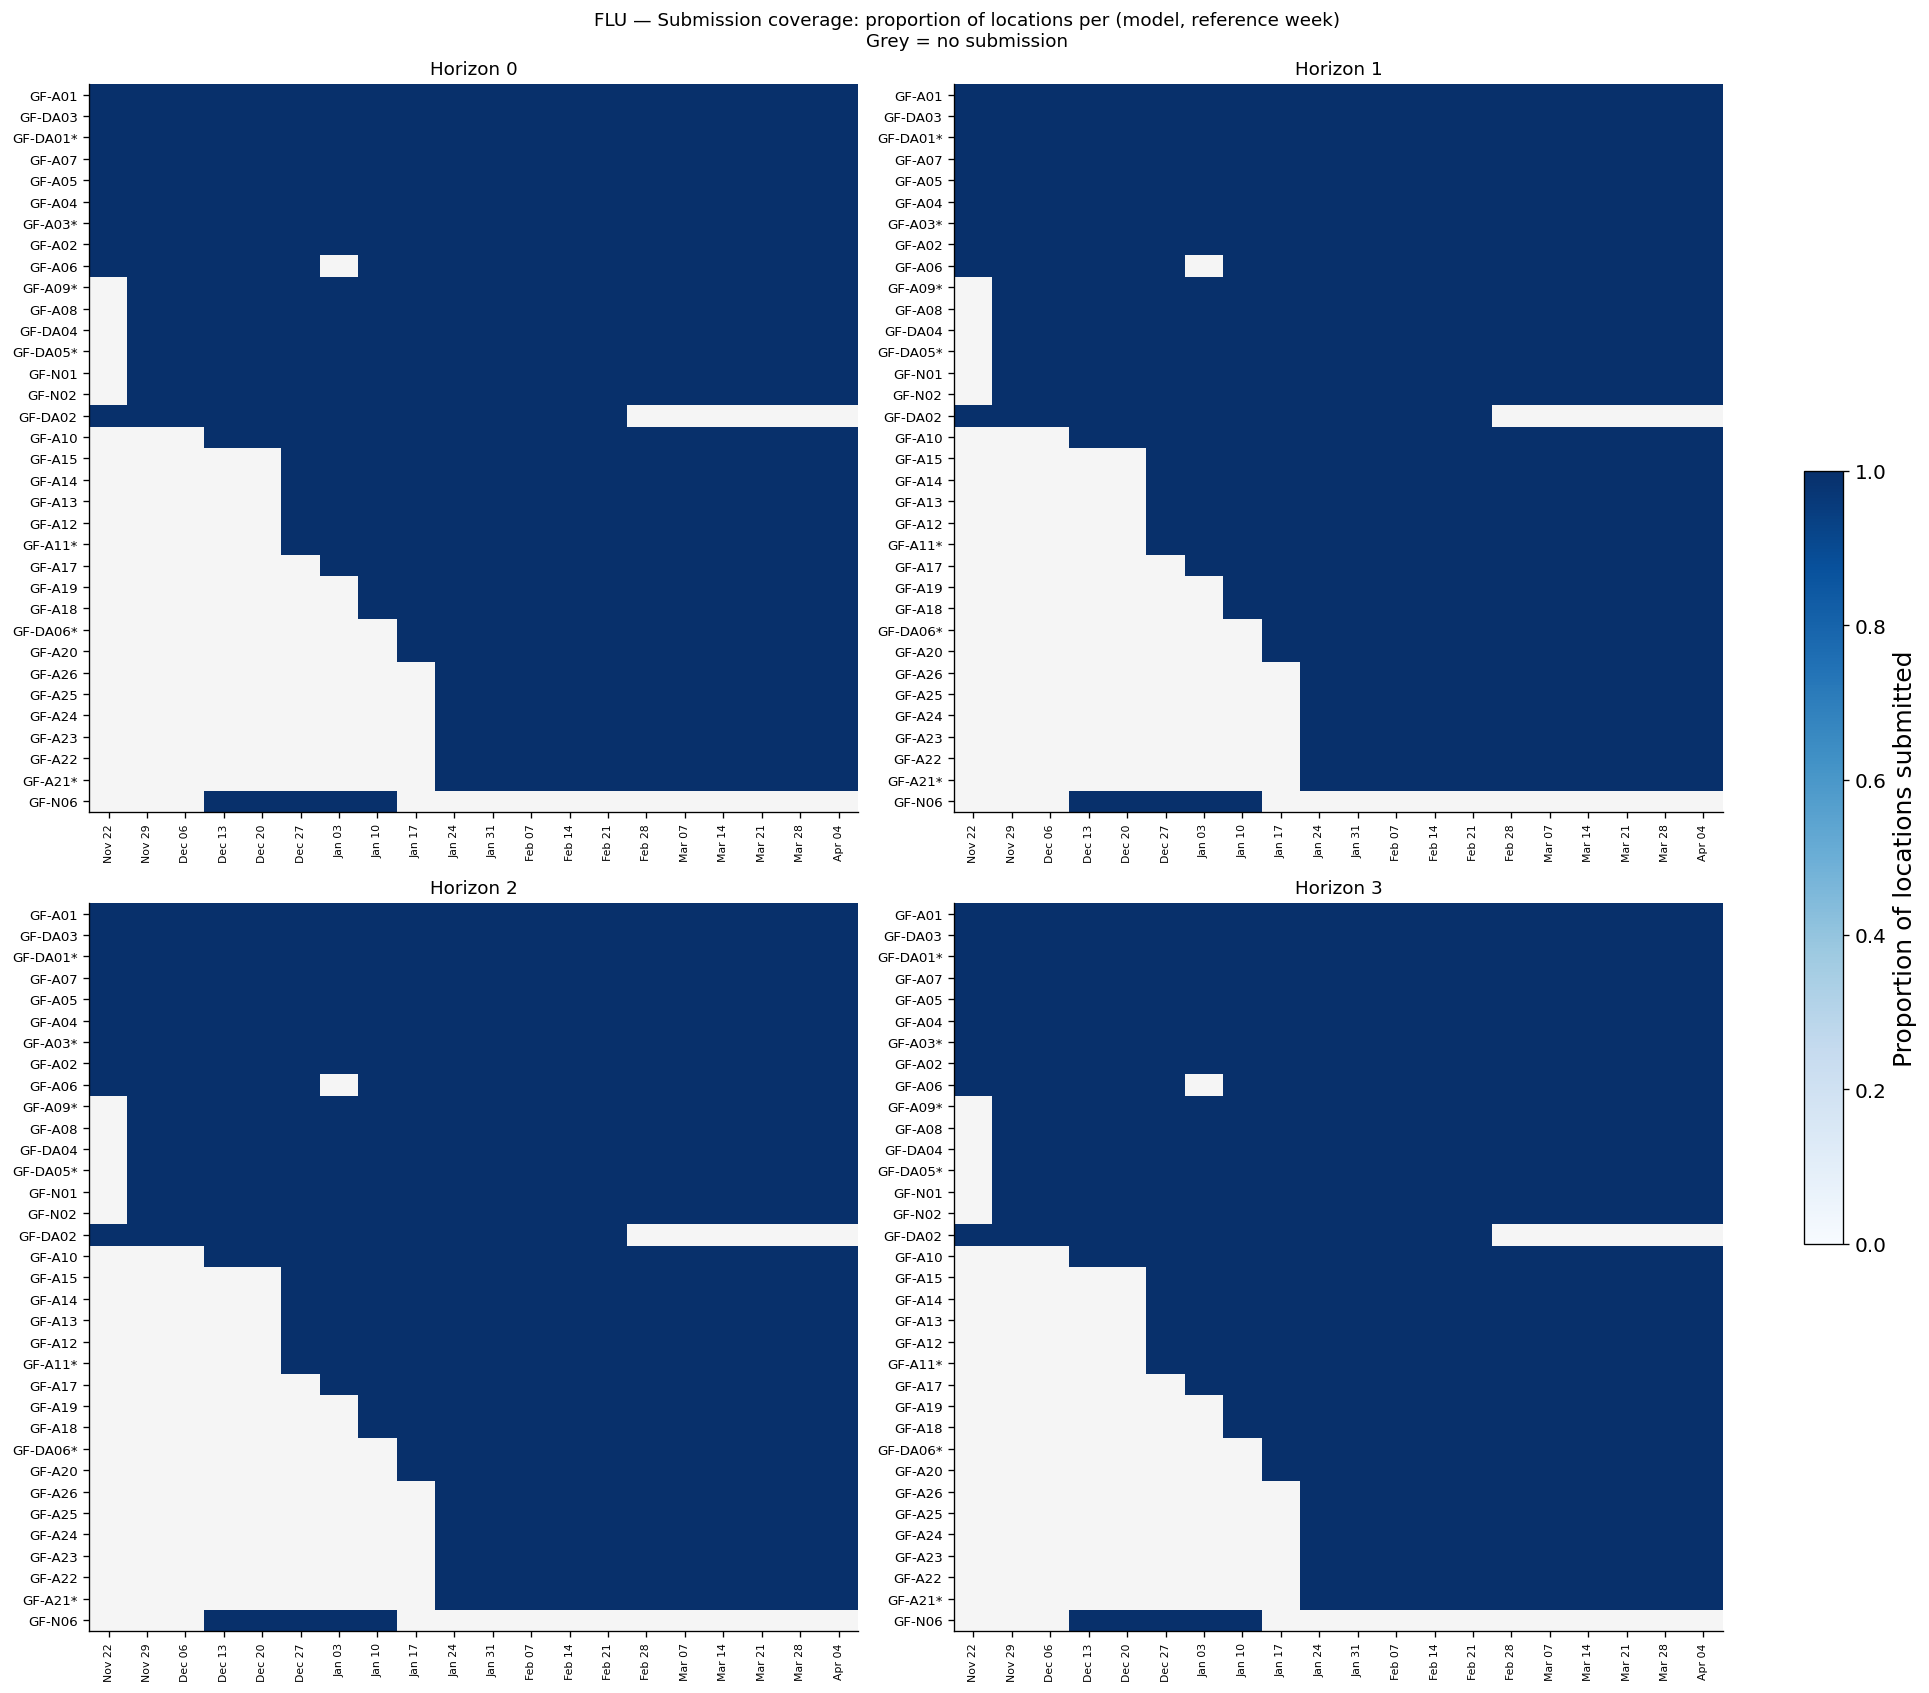

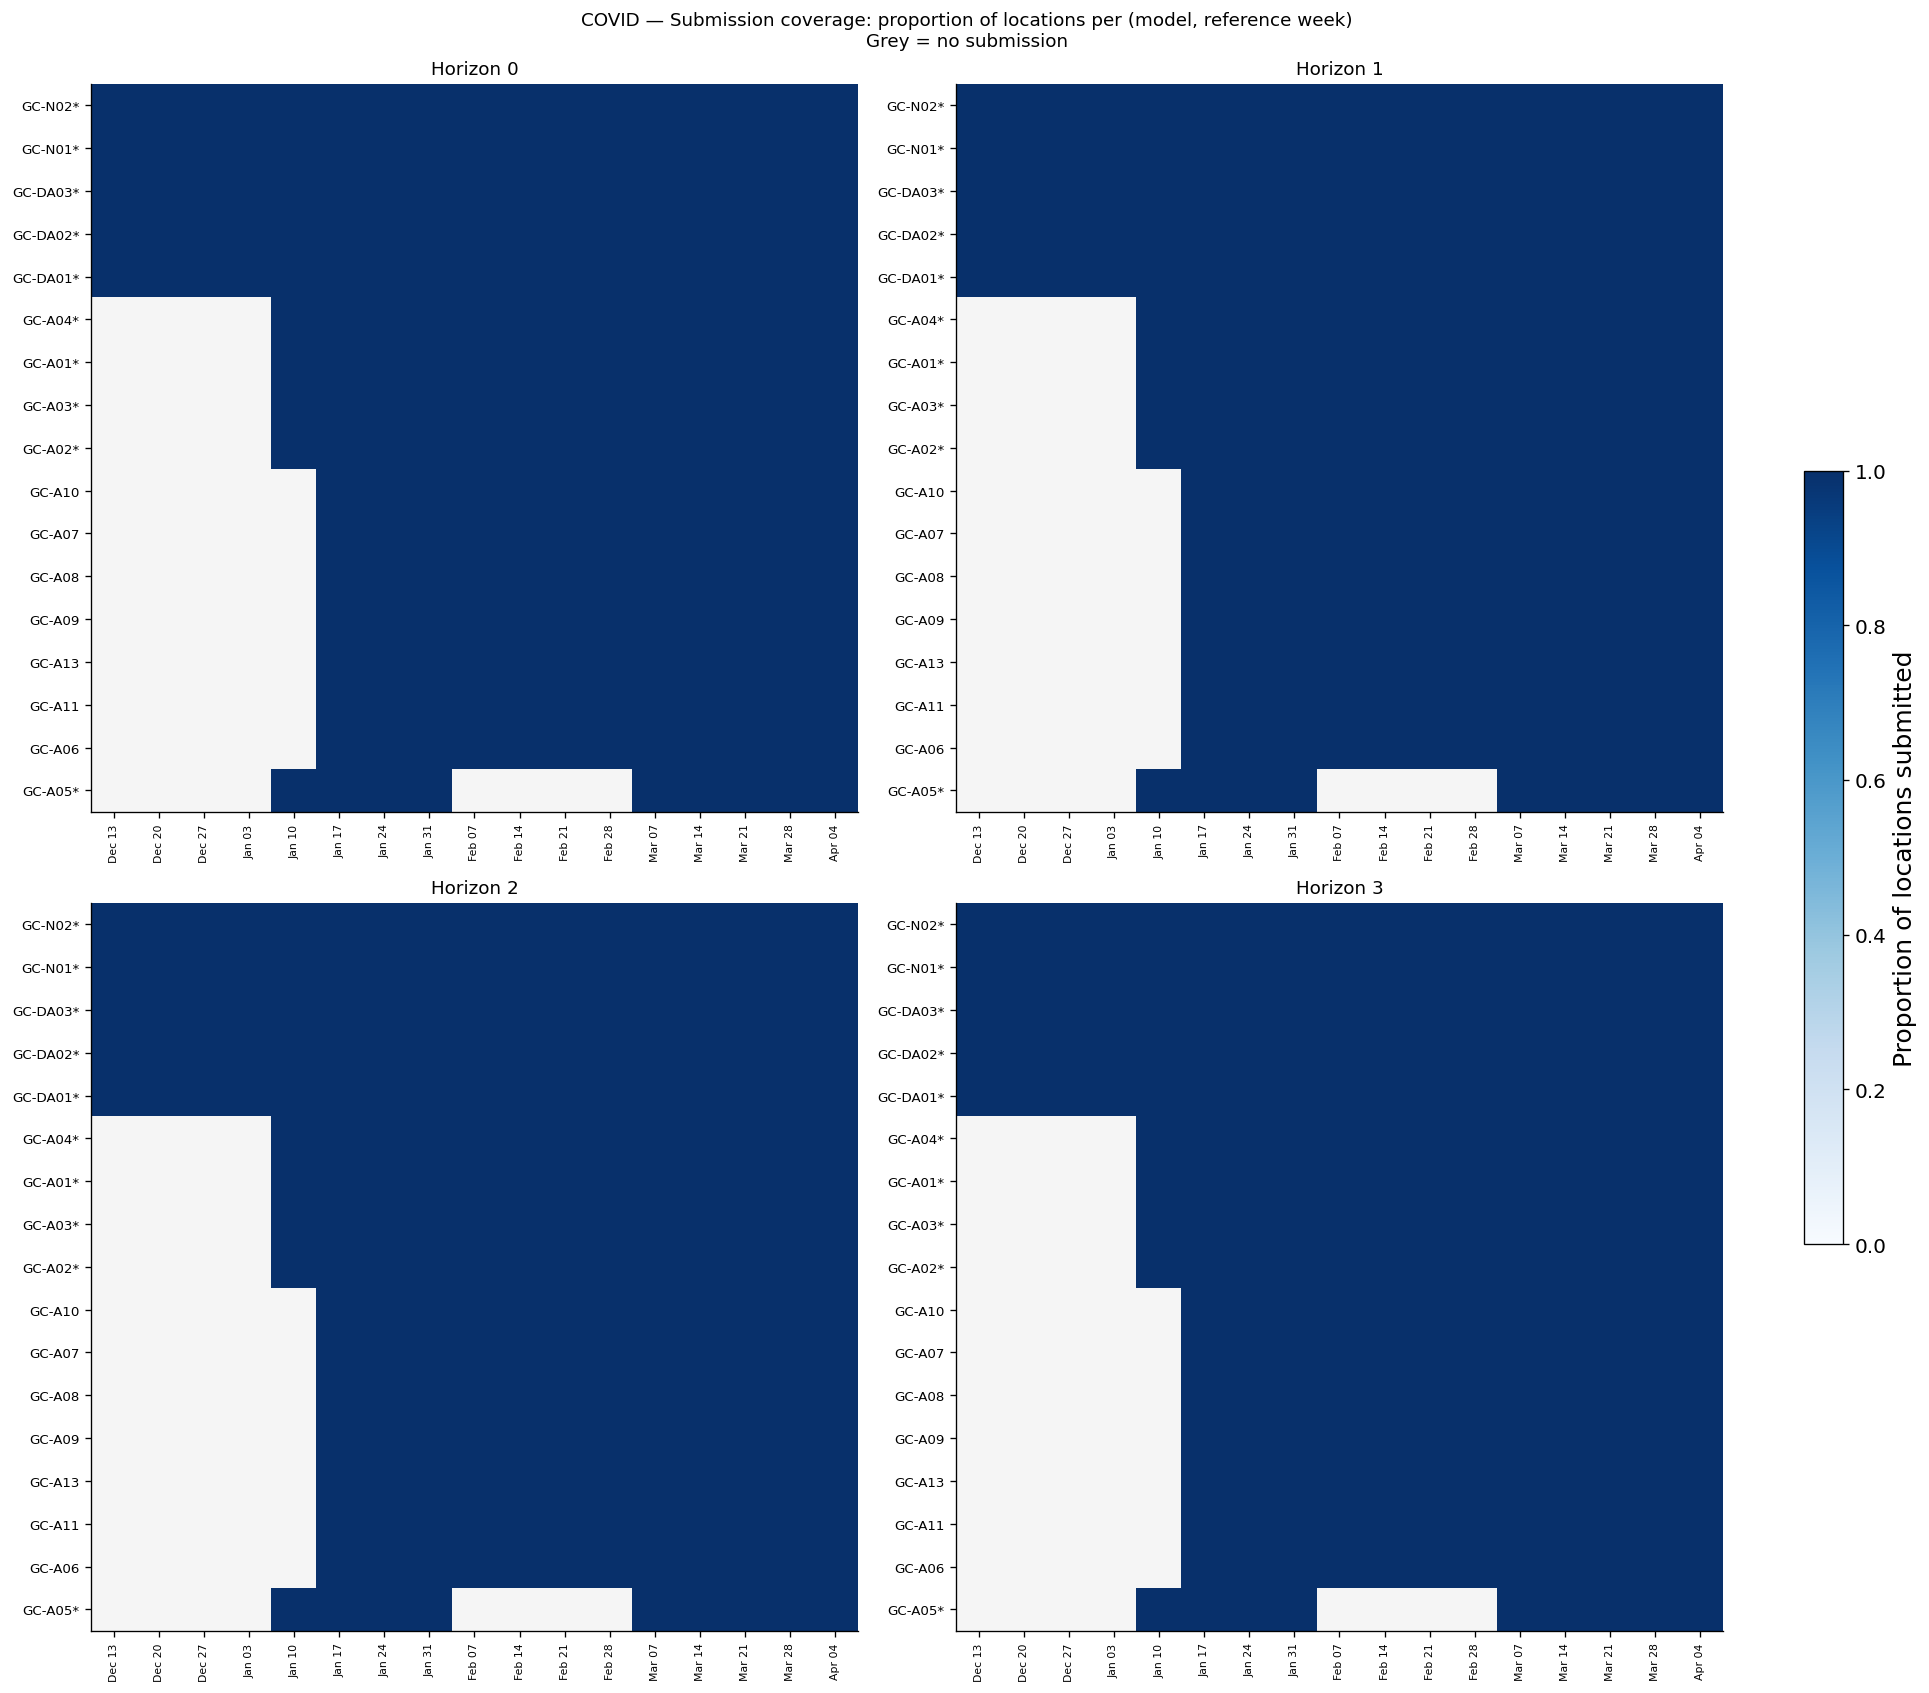

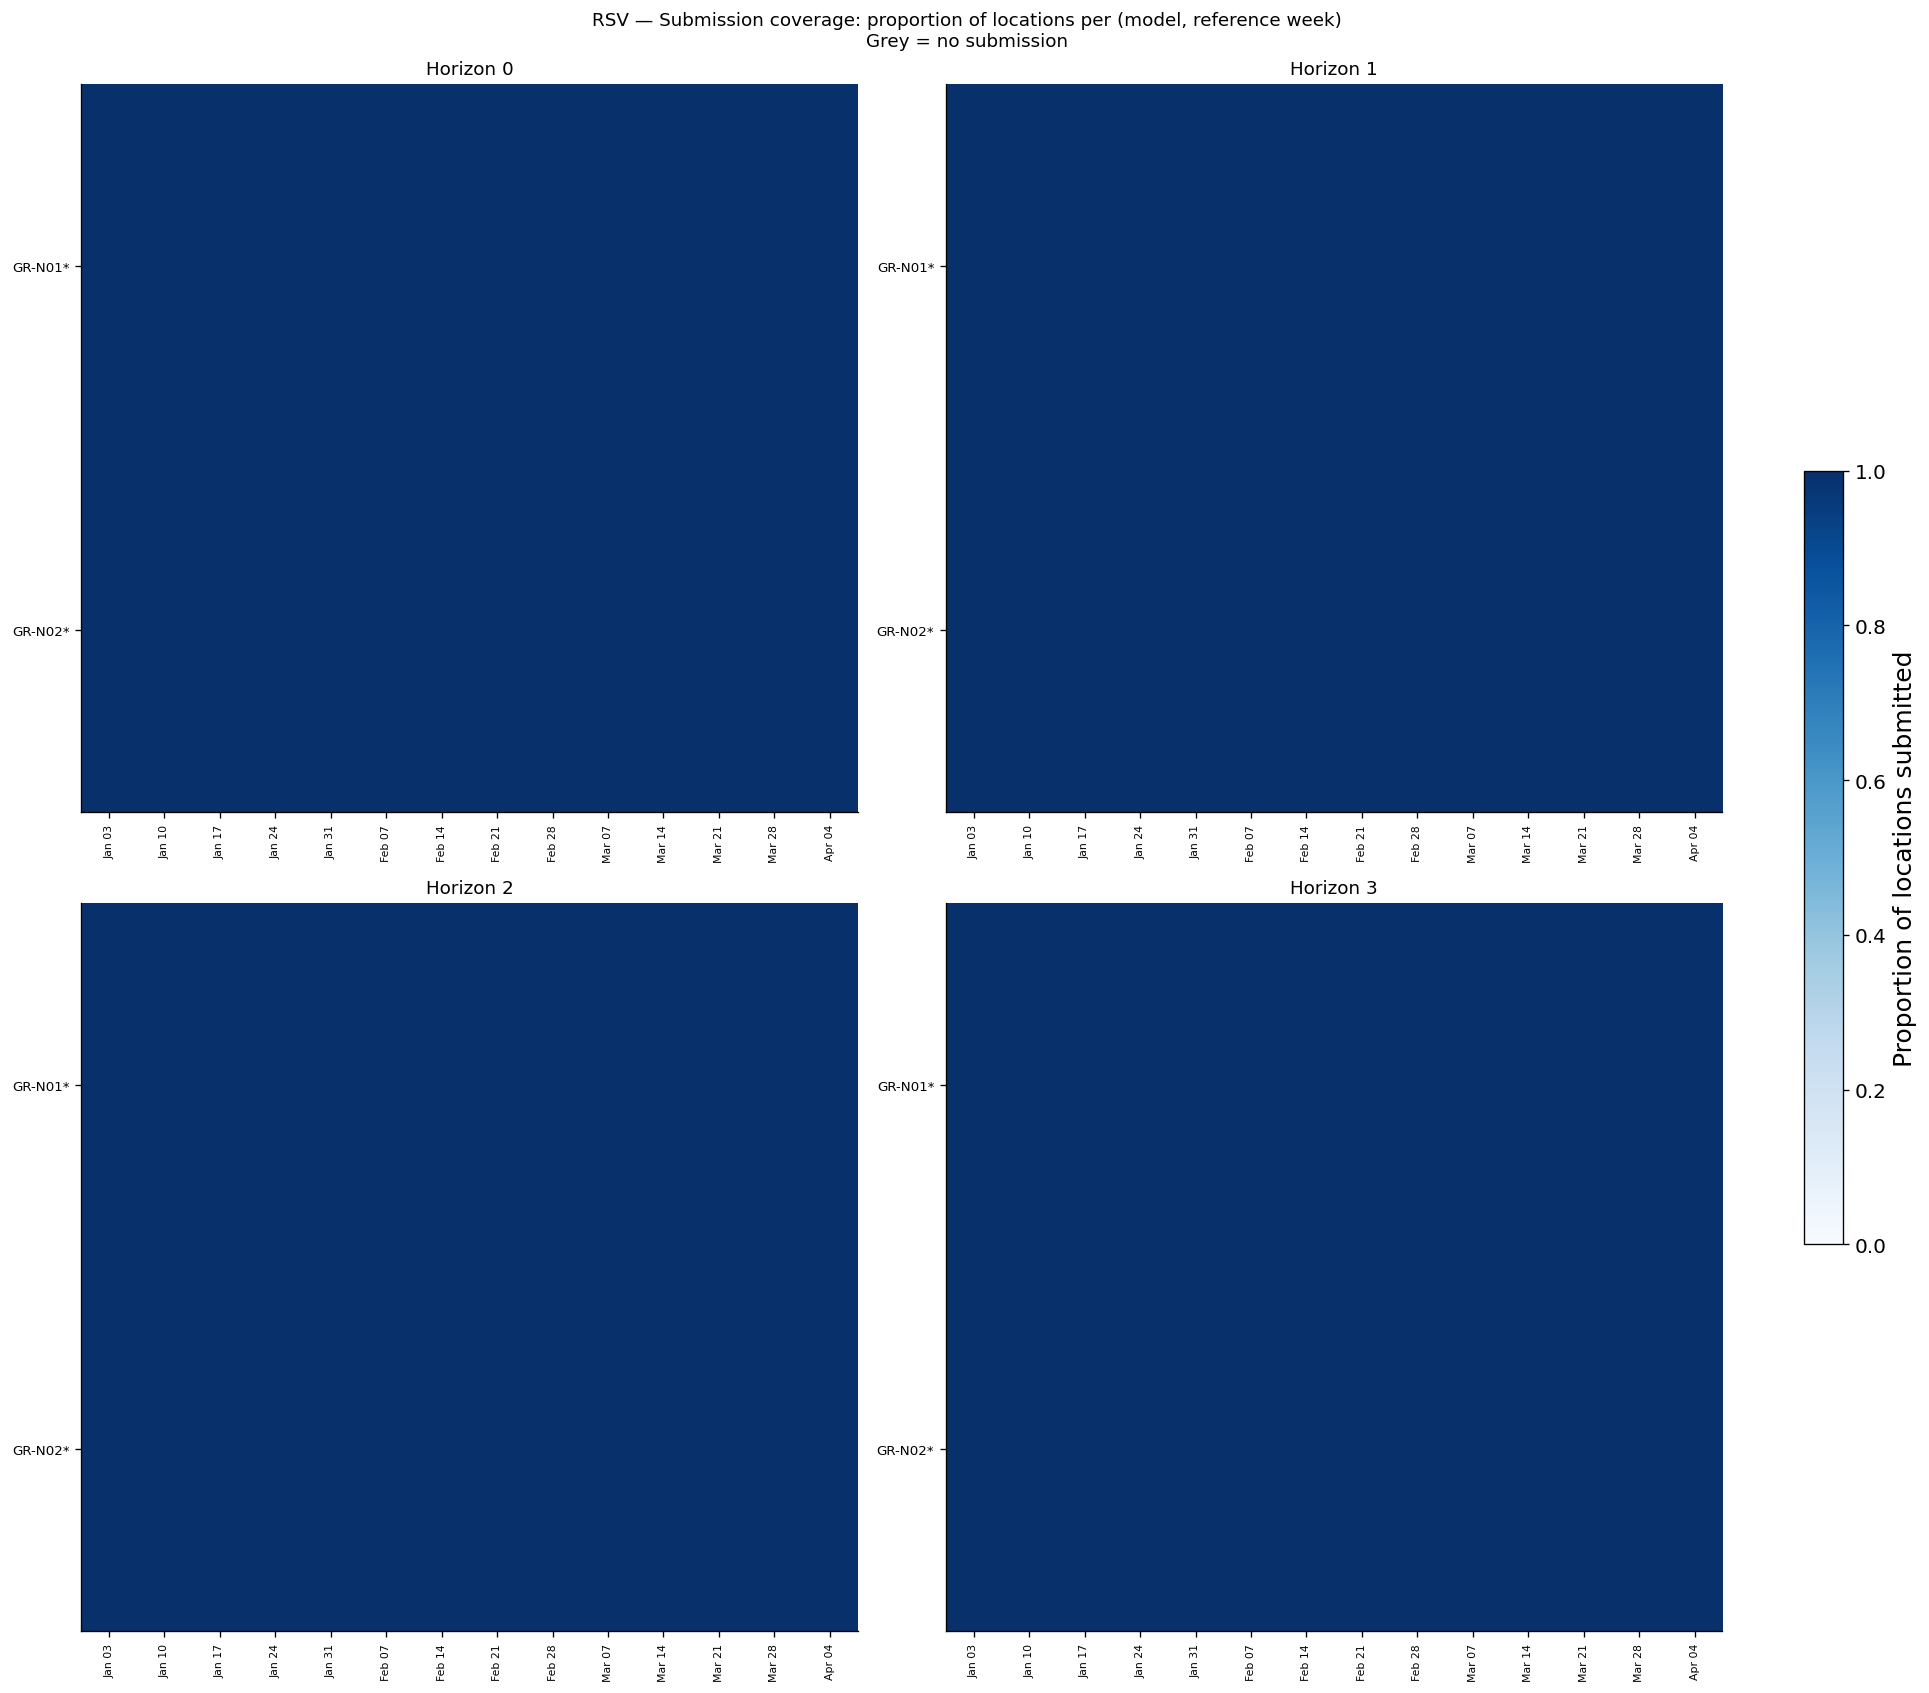

In [9]:
for disease in DISEASES:
    hub = GOOGLE_HUBS[disease]
    scores = scores_by_disease[disease]

    # Load forecasts to get coverage independent of truth availability
    forecasts_hm = pd.read_parquet(hub.forecasts_path)
    forecasts_hm = forecasts_hm[
        (forecasts_hm["target"] == hub.target_name) &
        (~forecasts_hm["location"].isin(EXCLUDE_LOCS))
    ]

    all_dates_hm  = sorted(forecasts_hm["reference_date"].dropna().unique())
    all_horizons  = sorted(forecasts_hm["horizon"].dropna().unique())
    all_horizons = [h for h in all_horizons if h >= 0]

    loc_cov = (
        forecasts_hm.groupby(["model_id", "reference_date", "horizon"])["location"]
        .nunique()
        .div(N_LOCS)
        .reset_index(name="prop_locs")
    )

    model_order = (
        scores.groupby("model_id").size()
        .sort_values(ascending=False)
        .index.tolist()
    )

    P.plot_coverage_heatmap(
        loc_cov, model_order, all_dates_hm, all_horizons, N_LOCS,
        hub_label=disease.upper(),
        model_labels=MODEL_SHORT_NAMES[disease],
    )

## Cross-Hub Comparison

Approach:
- Select top CDC models (by mean log WIS, ≥80% task coverage) + CDC ensemble + CDC baseline + Google CDC submission
- Restrict to tasks common to both the internal hub and CDC hub
- Compute pairwise relative WIS across the combined pool, with the CDC ensemble as baseline (= 1.0)

In [10]:
CDC_ELIGIBILITY_THRESHOLD = 0.80
CDC_TOP_N = 10  # how many top eligible CDC models to include in the plot

CDC_GOOGLE_PINK = C.GOOGLE_PINK
CDC_ENSEMBLE_BLACK = C.HUB_BLACK
CDC_BASELINE_GREY = C.HUB_BLACK
CDC_OTHER_GREY = C.OTHER_GREY

crosshub_data = {}  # disease -> {"scores": combined df, "colours": dict, "ensemble": str}

for disease in DISEASES:
    cdc_hub   = CDC_HUBS[disease]
    google_df = scores_by_disease[disease]

    # Load CDC scores
    cdc_scores = pd.read_parquet(cdc_hub.scores_path)
    cdc_scores = cdc_scores[~cdc_scores["location"].isin(EXCLUDE_LOCS)].copy()

    # Determine CDC eligibility
    cdc_task_space = cdc_scores.groupby(["reference_date", "horizon", "location"]).size()
    cdc_max_tasks  = len(cdc_task_space)
    cdc_model_tasks = cdc_scores.groupby("model_id").size()
    cdc_eligible = sorted(
        cdc_model_tasks[cdc_model_tasks / cdc_max_tasks >= CDC_ELIGIBILITY_THRESHOLD].index
    )

    # Top N CDC eligible models by mean log WIS
    cdc_elig_scores = cdc_scores[cdc_scores["model_id"].isin(cdc_eligible)]
    cdc_top = (
        cdc_elig_scores.groupby("model_id")["log_wis"]
        .mean()
        .nsmallest(CDC_TOP_N)
        .index.tolist()
    )

    # Always include hub special models
    always_include = set(cdc_hub.hub_model_ids) | {cdc_hub.google_id}
    always_include.discard("")  # remove empty strings from hubs without google_id etc.
    cdc_keep = set(cdc_top) | always_include

    cdc_filtered = cdc_scores[cdc_scores["model_id"].isin(cdc_keep)].copy()

    # Restrict to tasks that exist in the Google internal hub (common tasks)
    google_tasks = google_df[["reference_date", "horizon", "location"]].drop_duplicates()
    cdc_on_common = cdc_filtered.merge(
        google_tasks, on=["reference_date", "horizon", "location"], how="inner"
    )
    google_on_common = google_df.merge(
        cdc_on_common[["reference_date", "horizon", "location"]].drop_duplicates(),
        on=["reference_date", "horizon", "location"], how="inner"
    )

    common_n = cdc_on_common[["reference_date", "horizon", "location"]].drop_duplicates().shape[0]
    print(f"{disease.upper()}: {common_n:,} common tasks | "
          f"{google_on_common['model_id'].nunique()} Google internal + "
          f"{cdc_on_common['model_id'].nunique()} CDC models")

    combined = pd.concat(
        [cdc_on_common[["model_id","reference_date","horizon","location","wis","log_wis"]],
         google_on_common[["model_id","reference_date","horizon","location","wis","log_wis"]]],
        ignore_index=True,
    )

    # Build colour dict
    google_colours = model_colours_by_disease[disease]
    cdc_colours = {}
    for m in cdc_on_common["model_id"].unique():
        if m == cdc_hub.ensemble_id:
            cdc_colours[m] = CDC_ENSEMBLE_BLACK
        elif m == cdc_hub.baseline_id:
            cdc_colours[m] = CDC_BASELINE_GREY
        elif m == cdc_hub.google_id:
            cdc_colours[m] = CDC_GOOGLE_PINK
        else:
            cdc_colours[m] = CDC_OTHER_GREY
    all_colours = {**google_colours, **cdc_colours}

    # Build hatch dict — Google internal models get type hatches, CDC models get none
    all_hatches = {**model_hatches_by_disease[disease]}  # CDC models absent → "" fallback

    crosshub_data[disease] = {
        "combined":   combined,
        "colours":    all_colours,
        "hatches":    all_hatches,
        "ensemble":   cdc_hub.ensemble_id,
        "cdc_models": set(cdc_on_common["model_id"].unique()),
    }

FLU: 3,588 common tasks | 34 Google internal + 14 CDC models
COVID: 2,808 common tasks | 17 Google internal + 6 CDC models
RSV: 2,184 common tasks | 2 Google internal + 3 CDC models


In [11]:
# Relative WIS tables per disease
crosshub_rel_by_disease = {}

for disease in DISEASES:
    d = crosshub_data[disease]
    combined    = d["combined"]
    all_colours = d["colours"]
    ensemble    = d["ensemble"]

    rel     = pairwise_relative_wis(combined, baseline_model=ensemble, score_col="wis")
    rel_log = pairwise_relative_wis(combined, baseline_model=ensemble, score_col="log_wis").rename(columns={"rel_wis": "rel_log_wis"})

    summary = (
        combined.groupby("model_id", as_index=False)
        .agg(
            n_tasks      = ("wis", "size"),
            mean_wis     = ("wis", "mean"),
            mean_log_wis = ("log_wis", "mean"),
        )
        .sort_values("mean_log_wis")
    )
    summary = summary.merge(rel, on="model_id", how="left").merge(rel_log, on="model_id", how="left")
    summary["origin"] = summary["model_id"].apply(
        lambda m: "CDC" if m in d["cdc_models"] else "Google internal"
    )
    summary["model_type"] = summary["model_id"].apply(
        lambda m: get_model_type(m) if m not in d["cdc_models"] else None
    )
    crosshub_rel_by_disease[disease] = summary

    # Apply short names for display (Google internal models only; CDC names unchanged)
    _lbl = MODEL_SHORT_NAMES[disease]
    _display = summary.copy()
    _display["model_id"] = _display["model_id"].map(lambda m: _lbl.get(m, m))

    print(f"\n{'='*70}")
    print(f"{disease.upper()} — Cross-hub comparison (relative to CDC ensemble = 1.0)")
    display(
        _display.style
        .apply(C.rel_wis_style, subset=["rel_wis"])
        .apply(C.rel_wis_style, subset=["rel_log_wis"])
        .background_gradient(cmap="RdYlGn_r", subset=["mean_wis", "mean_log_wis"], axis=0)
        .apply(C.model_type_style, subset=["model_type"])
        .format({
            "mean_wis":     "{:.2f}",
            "mean_log_wis": "{:.4f}",
            "rel_wis":      "{:.3f}",
            "rel_log_wis":  "{:.3f}",
        })
        .hide(axis="index")
    )


FLU — Cross-hub comparison (relative to CDC ensemble = 1.0)


model_id,n_tasks,mean_wis,mean_log_wis,rel_wis,rel_log_wis,origin,model_type
GF-A21*,1560,44.72,0.2430,0.989,1.023,Google internal,Adapted
GF-A24,1560,45.96,0.2518,1.016,1.060,Google internal,Adapted
GF-A23,1560,64.99,0.2671,1.449,1.128,Google internal,Adapted
GF-DA06*,1768,54.60,0.2679,1.050,1.104,Google internal,Hybrid
GF-A11*,2392,83.52,0.2750,0.993,1.042,Google internal,Adapted
GF-DA01*,3588,72.29,0.2881,0.798,0.897,Google internal,Hybrid
GF-A10,2808,97.91,0.2887,0.984,0.986,Google internal,Adapted
Google_SAI-FluEns,3588,89.13,0.2971,0.942,0.896,CDC,nan
GF-A09*,3328,88.95,0.3014,0.936,0.959,Google internal,Adapted
GF-A20,1768,60.33,0.3015,1.150,1.242,Google internal,Adapted



COVID — Cross-hub comparison (relative to CDC ensemble = 1.0)


model_id,n_tasks,mean_wis,mean_log_wis,rel_wis,rel_log_wis,origin,model_type
GC-A01*,1976,13.93,0.1705,0.871,0.984,Google internal,Adapted
Google_SAI-Ensemble,2808,16.88,0.1779,0.862,0.966,CDC,nan
GC-N02*,2808,16.53,0.1811,0.862,0.982,Google internal,Novel
GC-A02*,1976,14.80,0.1827,0.934,1.060,Google internal,Adapted
GC-A04*,1976,15.12,0.1832,0.953,1.064,Google internal,Adapted
GC-DA01*,2808,18.04,0.1840,0.923,0.998,Google internal,Hybrid
GC-A05*,1144,15.34,0.1858,0.907,1.085,Google internal,Adapted
CovidHub-ensemble,2808,19.80,0.1877,1.000,1.000,CDC,nan
GC-N01*,2808,18.09,0.1879,0.918,1.011,Google internal,Novel
GC-A09,1768,15.62,0.1973,1.040,1.142,Google internal,Adapted



RSV — Cross-hub comparison (relative to CDC ensemble = 1.0)


model_id,n_tasks,mean_wis,mean_log_wis,rel_wis,rel_log_wis,origin,model_type
Google_SAI-RSVEns,2184,19.95,0.1960,0.833,0.828,CDC,nan
GR-N02*,2184,19.31,0.2037,0.800,0.868,Google internal,Novel
GR-N01*,2184,23.06,0.2147,0.999,0.928,Google internal,Novel
RSVHub-ensemble,2184,23.08,0.2280,1.000,1.000,CDC,nan
RSVHub-baseline,2184,20.00,0.2571,0.836,1.162,CDC,nan


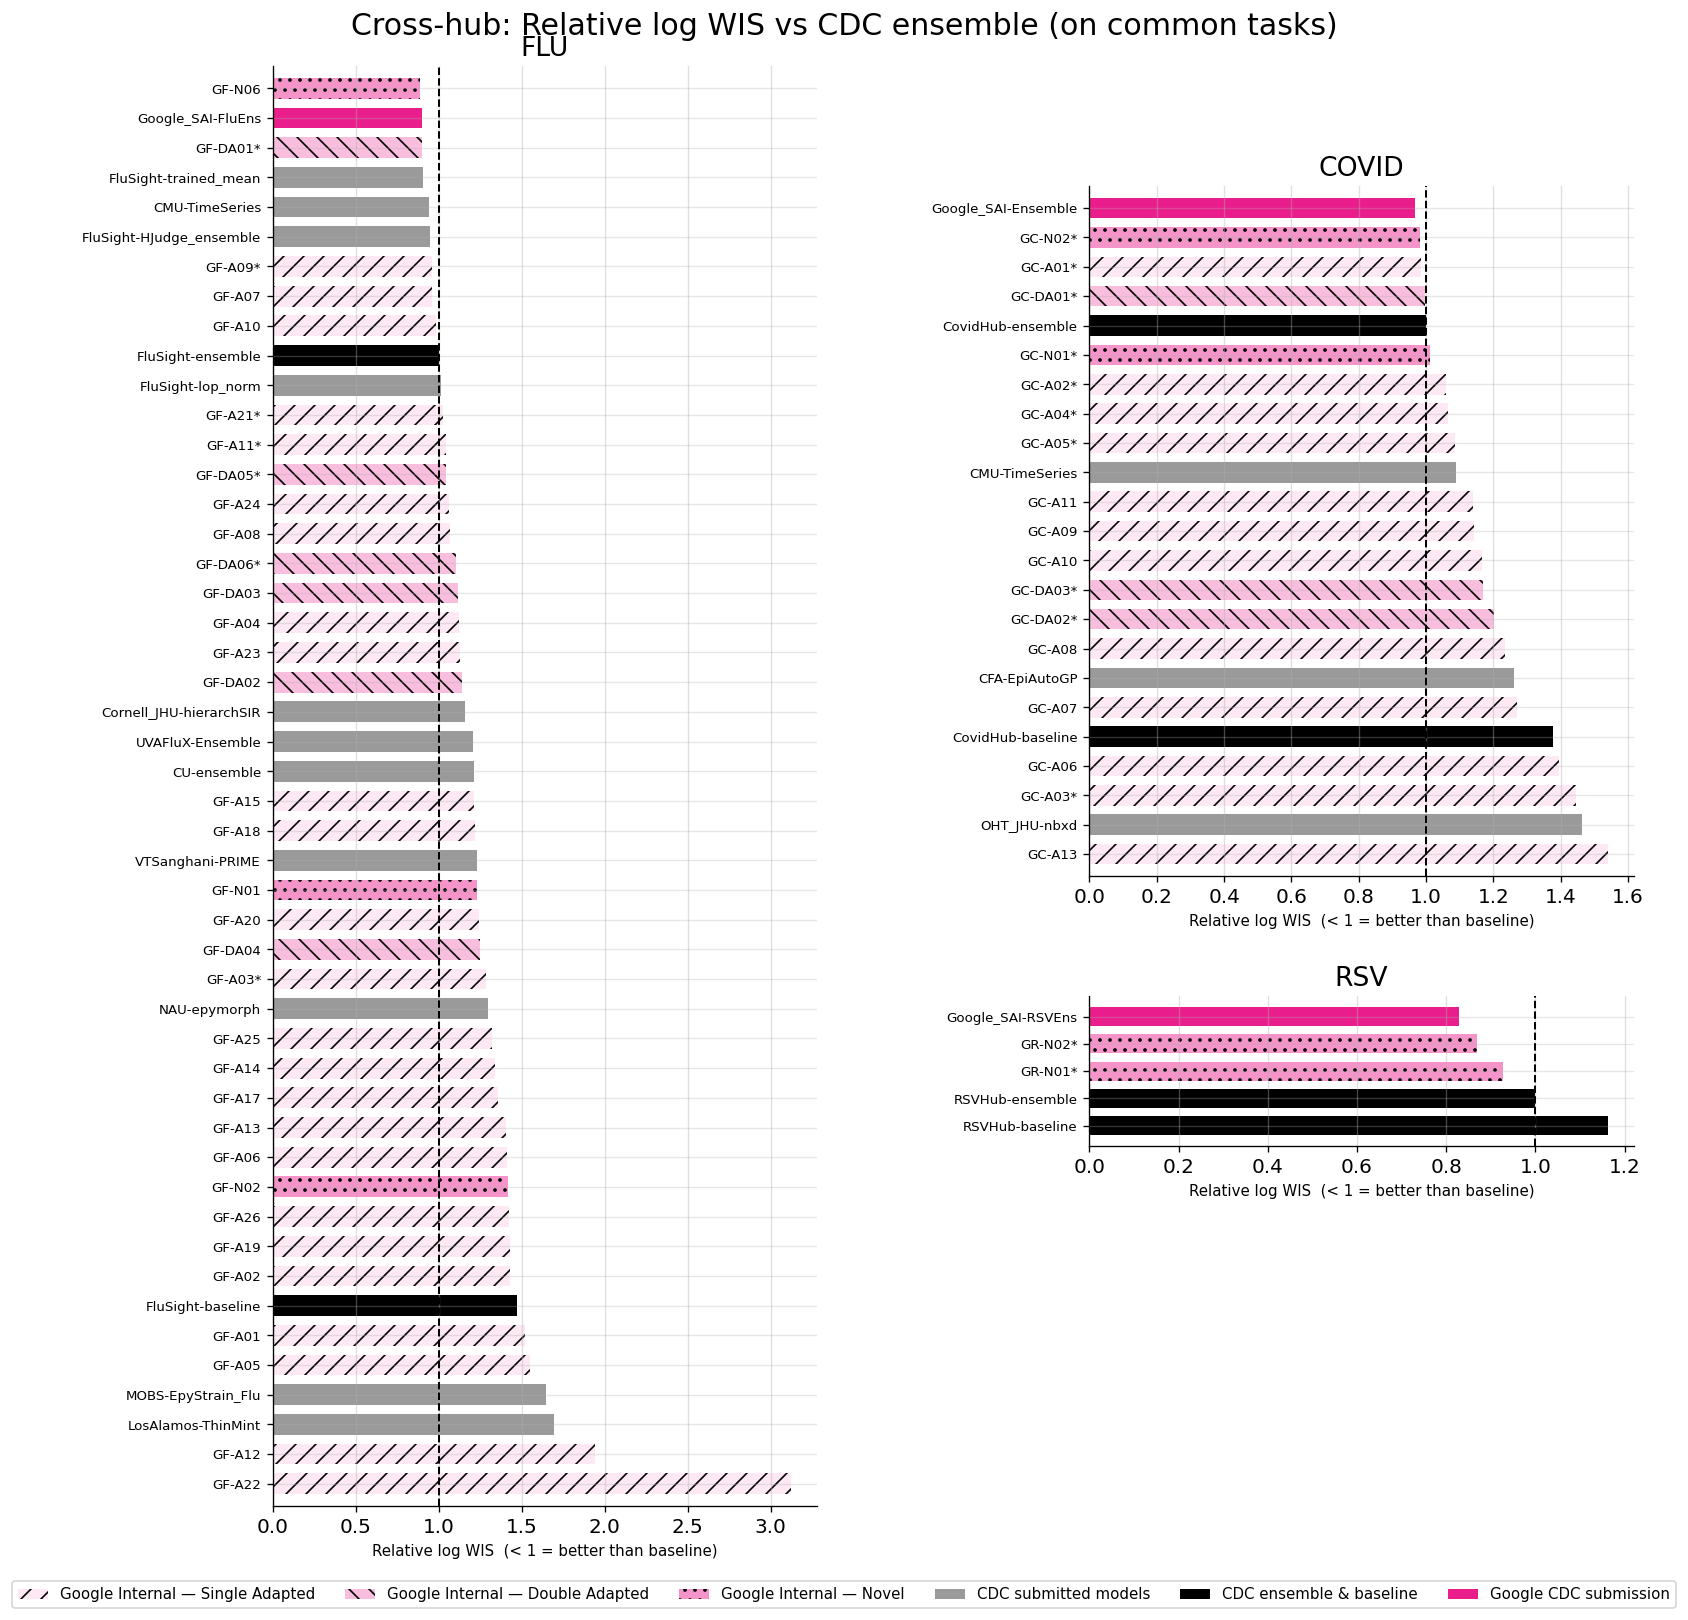

In [12]:
# Legend: list of (facecolor, hatch, label)
LEGEND_ENTRIES = [
    (C.TYPE_COLOURS["Adapted"], C.TYPE_HATCHES["Adapted"], "Google Internal — Single Adapted"),
    (C.TYPE_COLOURS["Hybrid"],  C.TYPE_HATCHES["Hybrid"],  "Google Internal — Double Adapted"),
    (C.TYPE_COLOURS["Novel"],   C.TYPE_HATCHES["Novel"],   "Google Internal — Novel"),
    (CDC_OTHER_GREY,    "", "CDC submitted models"),
    (CDC_ENSEMBLE_BLACK,"", "CDC ensemble & baseline"),
    (CDC_GOOGLE_PINK,   "", "Google CDC submission"),
]

P.plot_crosshub_rel_bars(
    crosshub_rel_by_disease,
    colours        = {d: crosshub_data[d]["colours"] for d in DISEASES},
    hatches        = {d: crosshub_data[d]["hatches"] for d in DISEASES},
    model_labels   = MODEL_SHORT_NAMES,
    legend_entries = LEGEND_ENTRIES,
    diseases       = DISEASES,
)


FLU


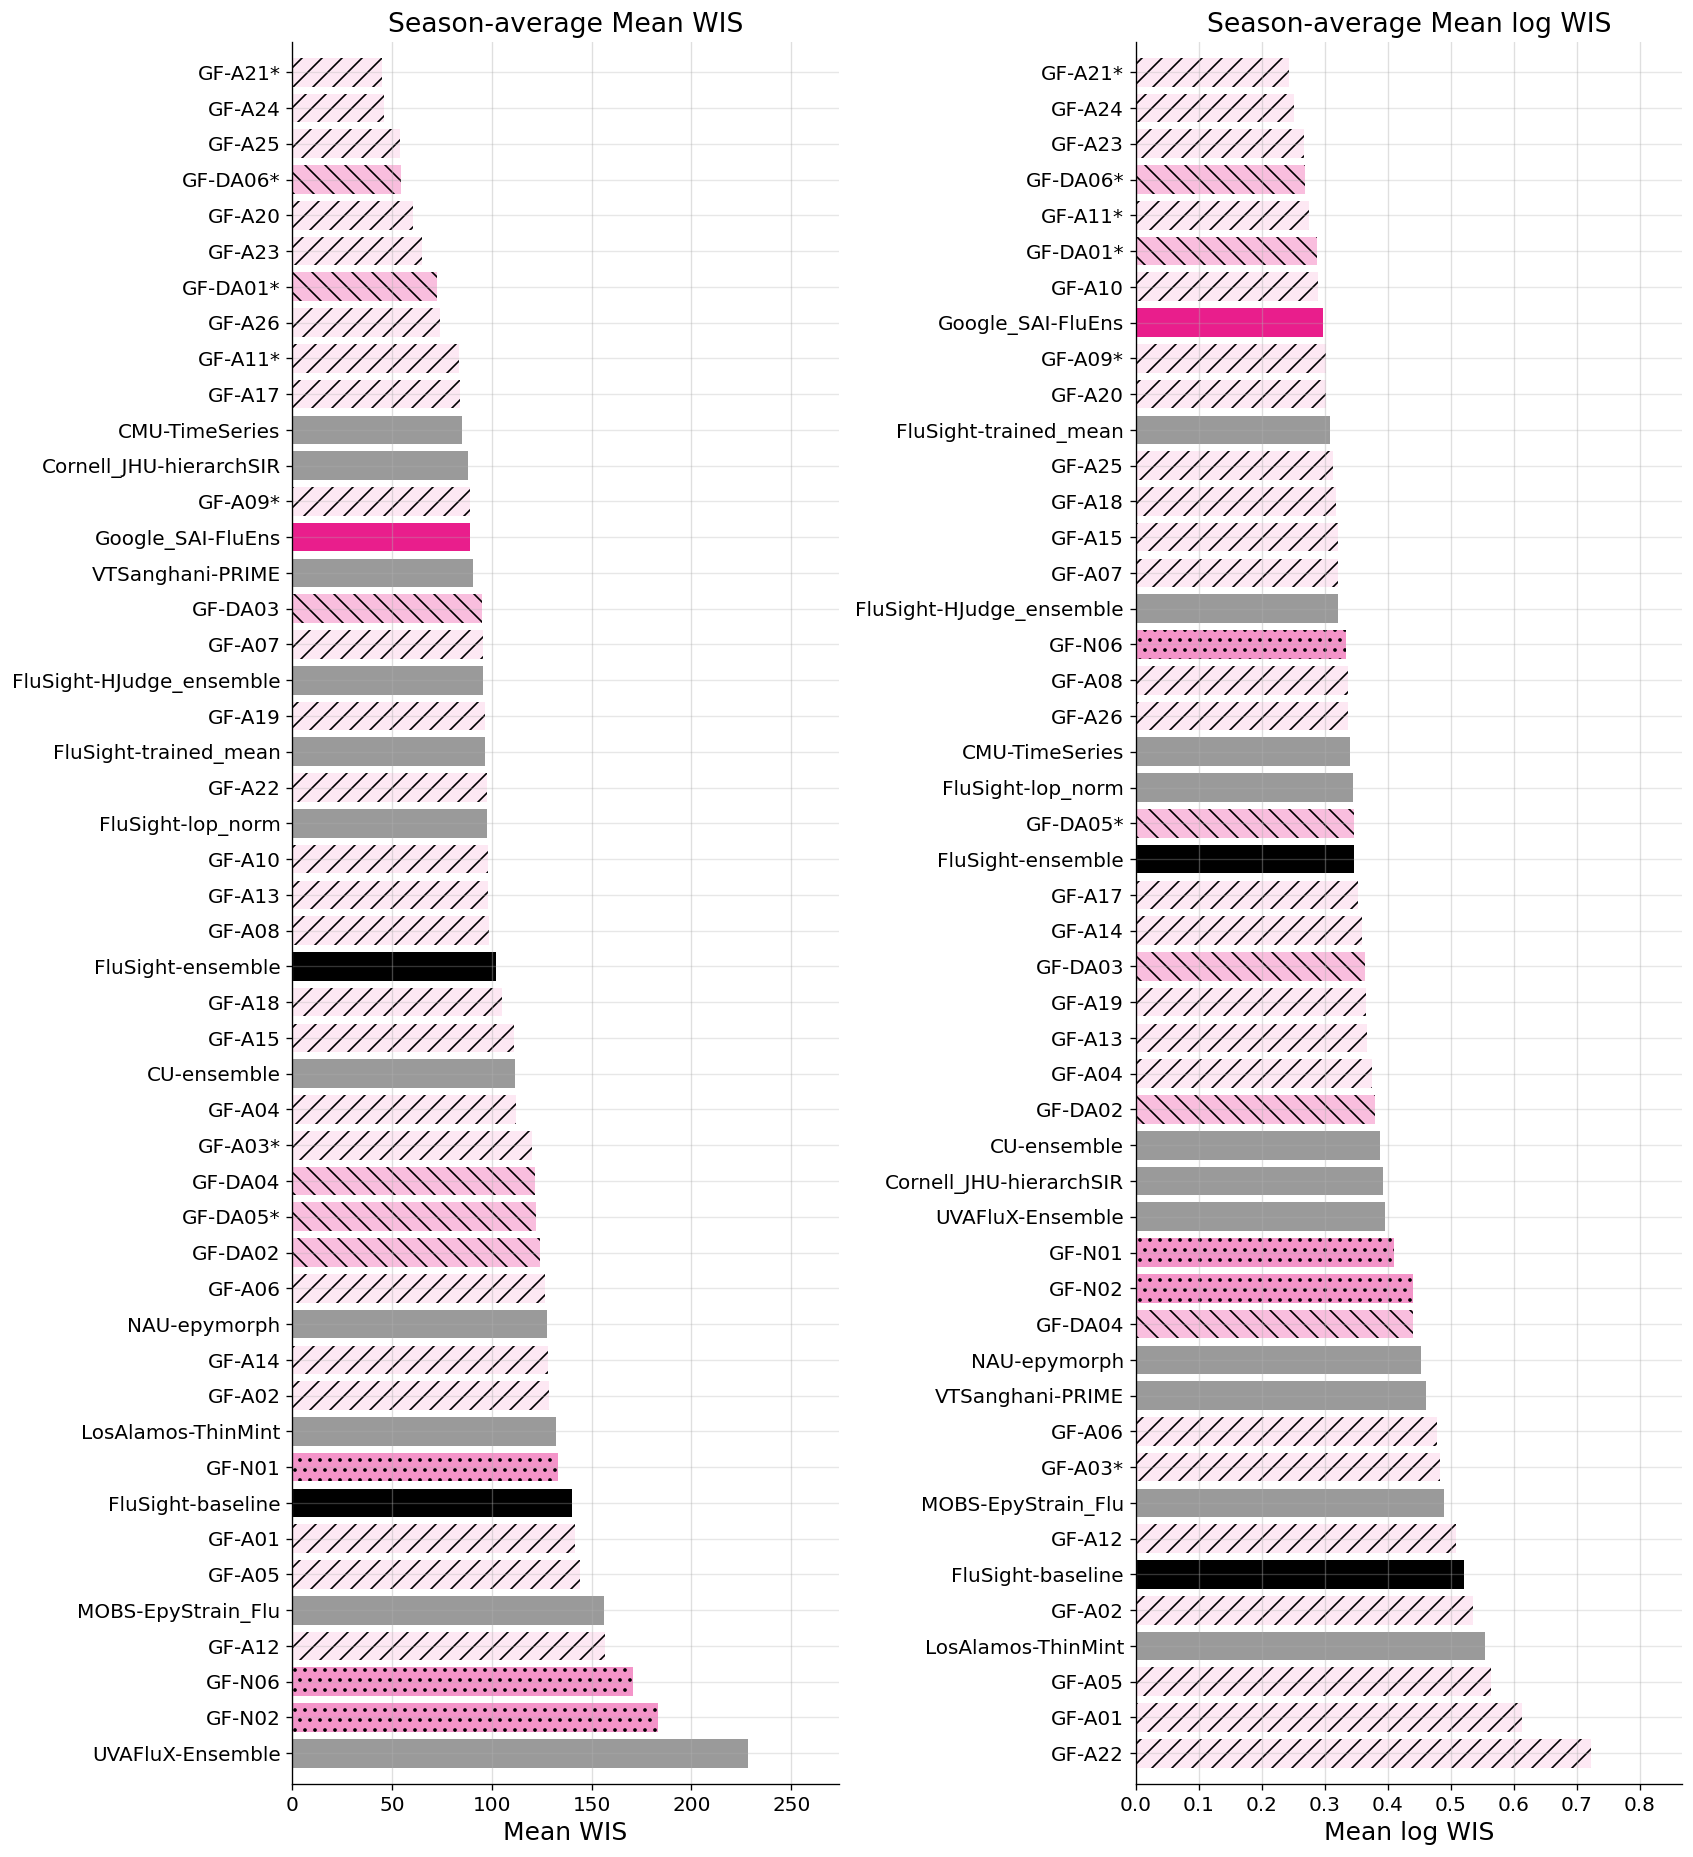


COVID


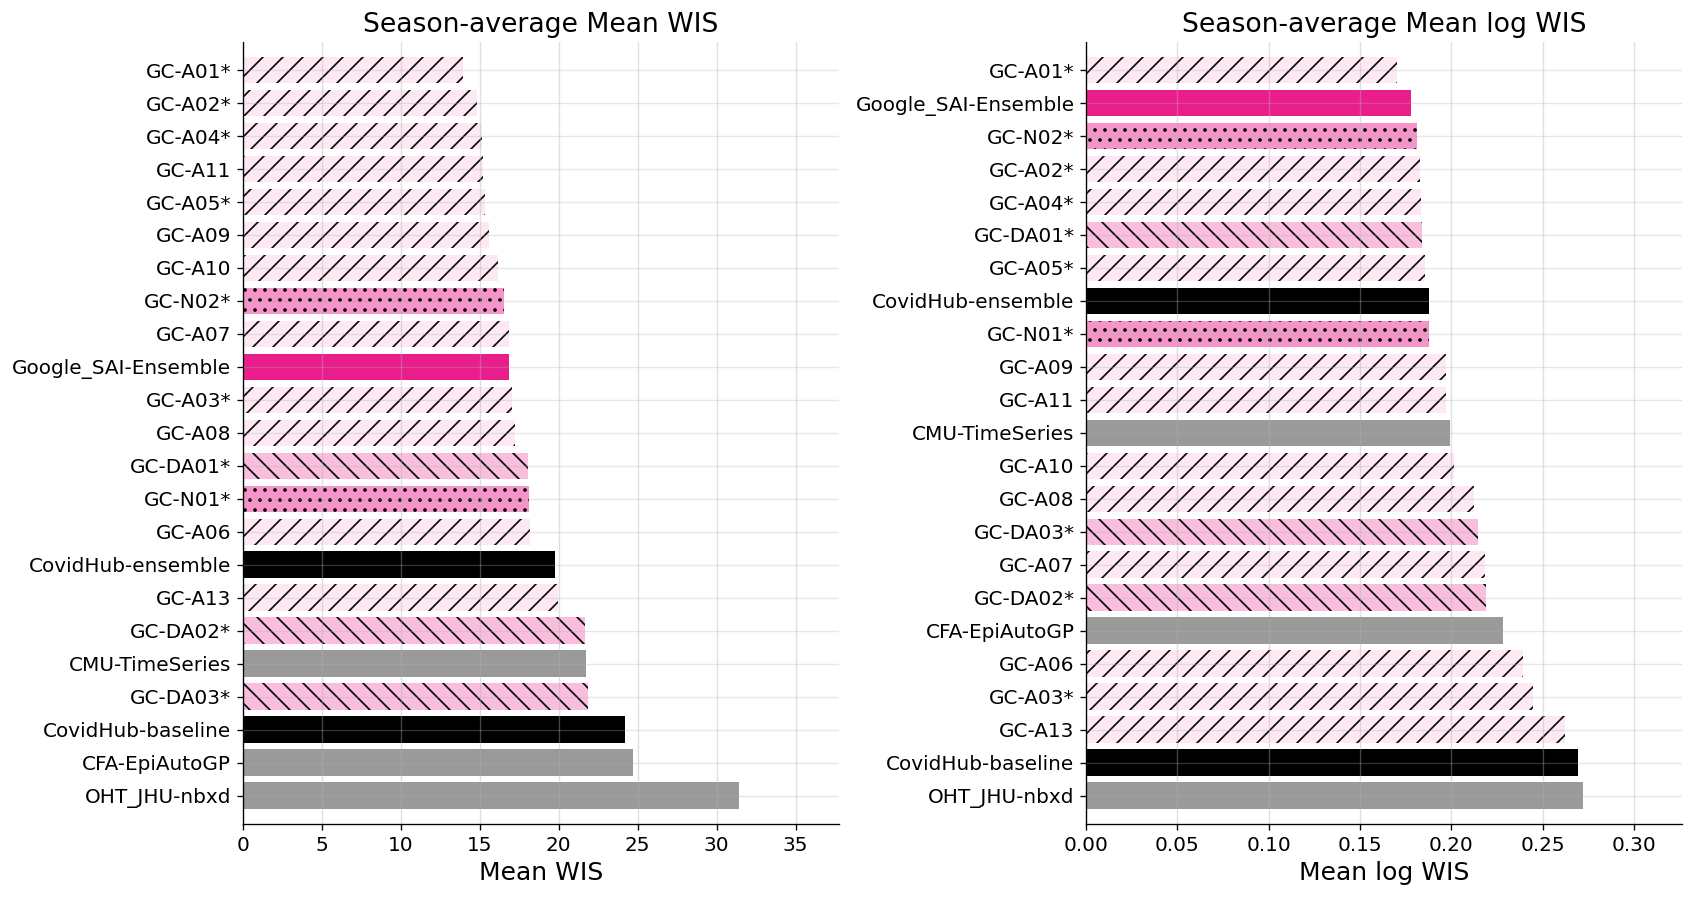


RSV


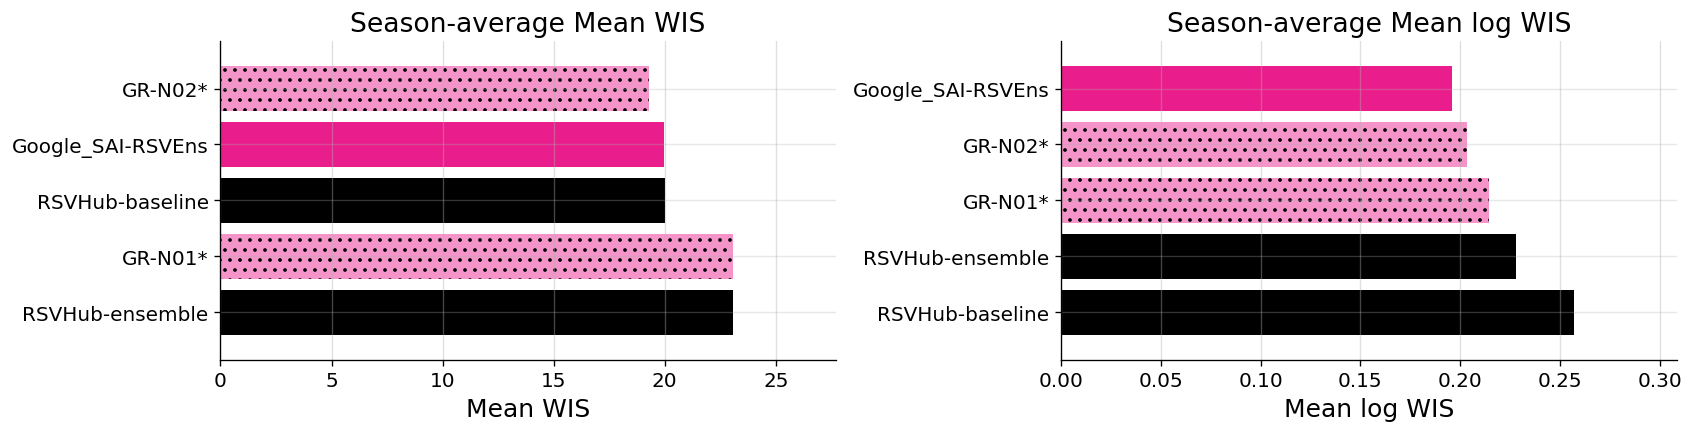

In [13]:
# Cross-hub: season-average WIS bars for each disease (combined Google + CDC)
for disease in DISEASES:
    d = crosshub_data[disease]
    summary = crosshub_rel_by_disease[disease]
    print(f"\n{disease.upper()}")
    P.plot_season_bars(summary, d["colours"], d["hatches"], MODEL_SHORT_NAMES[disease], include_n_tasks=False)

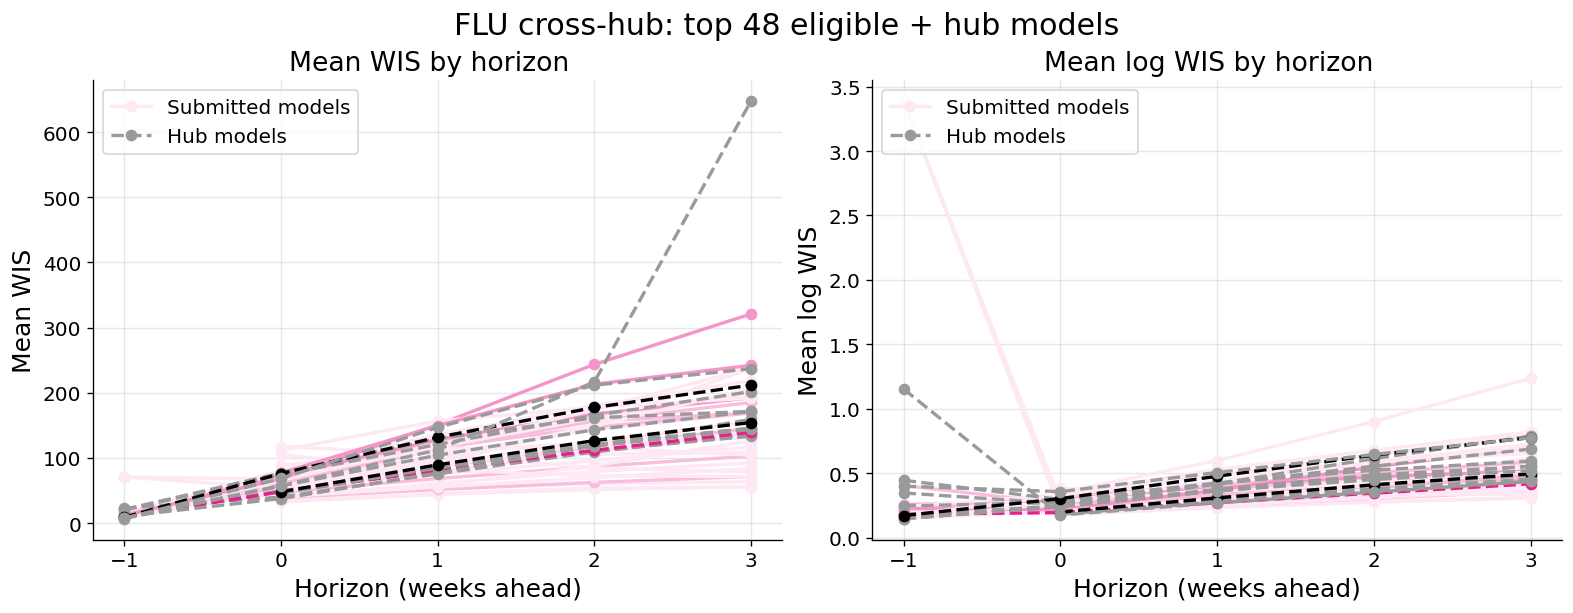

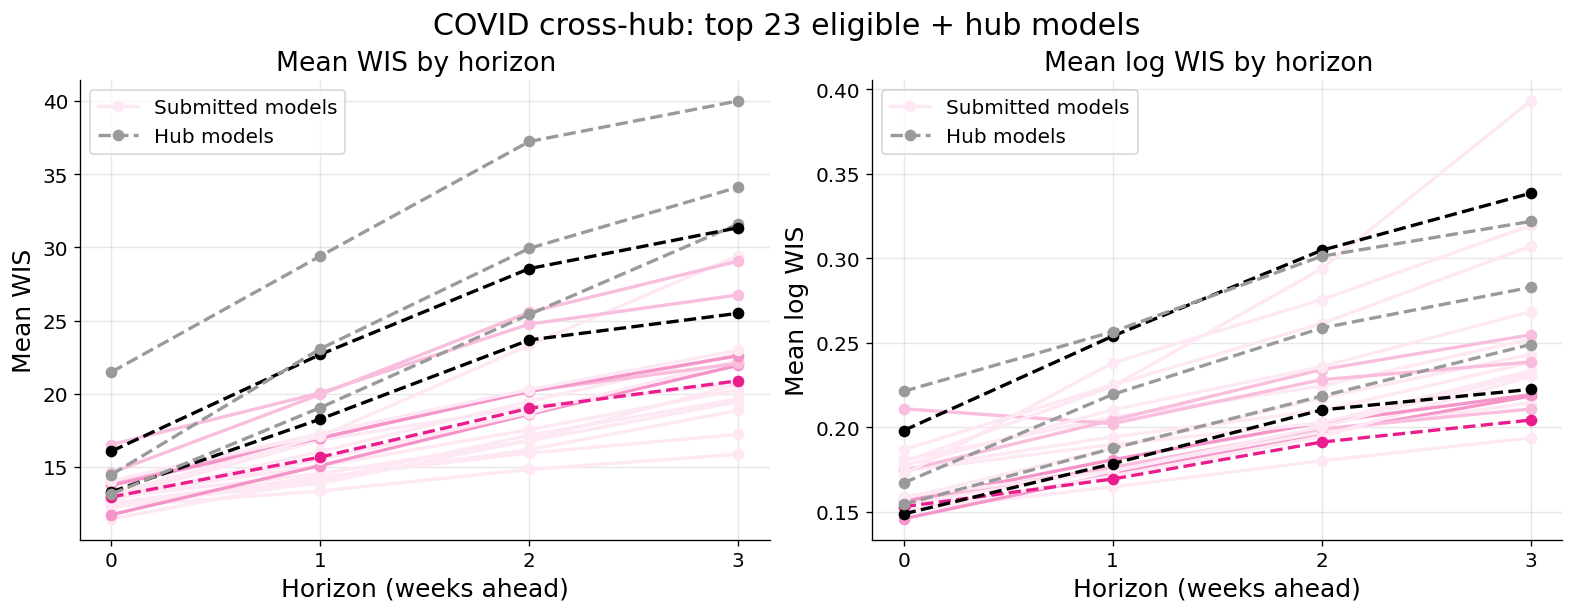

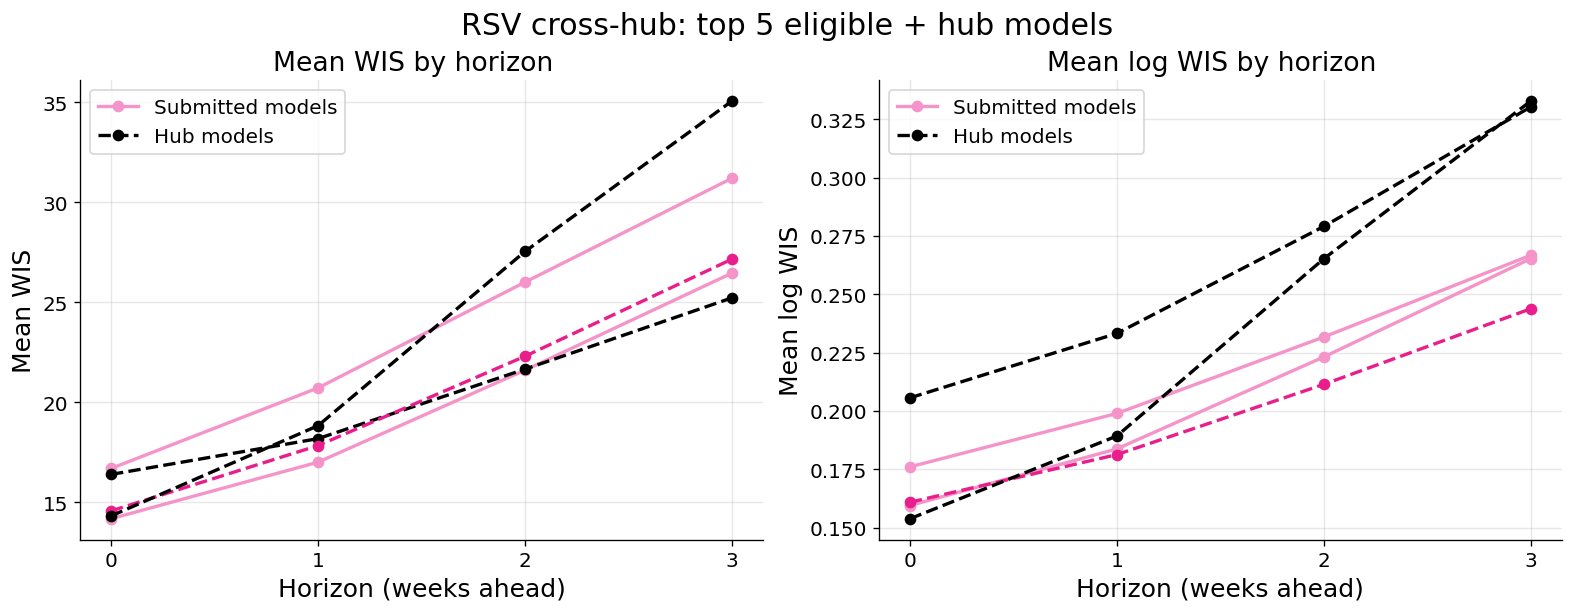

In [14]:
# Cross-hub: performance by horizon (Google internal vs CDC models)
for disease in DISEASES:
    d = crosshub_data[disease]
    combined = d["combined"]
    all_horizons = sorted(combined["horizon"].unique())

    by_hor_wis = (
        combined.groupby(["model_id", "horizon"])["wis"]
        .mean().unstack("horizon")
    )
    by_hor_log = (
        combined.groupby(["model_id", "horizon"])["log_wis"]
        .mean().unstack("horizon")
    )
    by_hor_wis = by_hor_wis.loc[by_hor_wis.mean(axis=1).sort_values().index]
    by_hor_log = by_hor_log.loc[by_hor_log.mean(axis=1).sort_values().index]

    P.plot_by_horizon(
        by_hor_wis, by_hor_log, all_horizons,
        model_colours=d["colours"],
        hub_models=d["cdc_models"],
        top_n=len(by_hor_wis),
        hub_label=f"{disease.upper()} cross-hub",
    )